# Data Cleaning

In [ ]:
# merge dataset

import pandas as pd
import json

files = [
    "3awal.json",
    "brainrot464.json",
    "brainrot467.json",
    "brainrot531.json",
    "doomscrolling522.json"
]

all_data = []

import json
for f in files:
    with open(f, "r", encoding="utf-8") as file:
        all_data.extend(json.load(file))

df = pd.DataFrame(all_data)

print(len(df))

1984


In [ ]:
# drop duplicate

df = df.drop_duplicates(subset = "videoId")
df

,videoId,title,channel,views,likes,comments,publishedAt,duration,region
0,gPPyFX5zi2k,Cara Memperbaiki Otak yang Terlanjur Brainrot,Edutektif,318462,18204,411,2025-12-05T11:30:55Z,PT14M1S,Unknown
1,2S1Xts88D4o,"Cara Memulihkan Fungsi Otak - brainrot, kekuat...",Akbar Abi,1851297,118136,2820,2025-07-15T09:15:00Z,PT22M24S,Unknown
2,H2EW4ReHHJk,Cara Mengingat Apapun yang Kamu Pelajari (Anti...,Zahid Ibrahim,79533,4091,57,2025-07-14T02:21:43Z,PT24M44S,Unknown
3,ApcaSz3MYvQ,Brainrot: Cara Mengatasi Kecanduan Scrolling &...,Stefanus Kurnia Suryaputra,94272,5406,346,2025-09-30T08:30:06Z,PT10M42S,Unknown
4,LYaduvtuSqg,Cara Memperbaiki Otak yang Terlanjur Brainrot,Upgrade Hidup,6830,353,106,2026-02-02T02:00:28Z,PT10M8S,Unknown
...,...,...,...,...,...,...,...,...,...
1885,0gzPnv_8eU0,8HRS OF DOOMSCROLLING VS 15MINS IN MLBB 😂 #for...,Envalis,1423,14,1,2026-04-18T08:59:26Z,PT14S,Unknown
1889,8q5Mg71k0jw,Stop doomscrolling #skyrim #ambient #advice #m...,Fookin Jerry,4334,964,45,2026-04-16T21:30:01Z,PT50S,Unknown
1893,mEnL59hLM2w,I loved the doom scrolling#justinbieber #biebe...,42 LIVE,1114,16,2,2026-04-12T19:09:42Z,PT1M25S,Unknown
1901,D9LVc8gd0lQ,Anti Doomscrolling activities that cost nothing,Dr. Kaunain Baig,1687,9,0,2026-04-13T17:47:31Z,PT37S,Unknown


In [ ]:
# checking missing value

df.isnull().sum()

,0
videoId,0
title,0
channel,0
views,0
likes,0
comments,0
publishedAt,0
duration,0
region,0


In [ ]:
#make sure the data type were correct

df["views"] = df["views"].astype(int)
df["likes"] = df["likes"].astype(int)
df["comments"] = df["comments"].astype(int)

In [ ]:
# change duration format

import re

def iso8601_to_seconds(duration):
    match = re.match(r'PT((\d+)H)?((\d+)M)?((\d+)S)?', duration)

    hours = int(match.group(2)) if match.group(2) else 0
    minutes = int(match.group(4)) if match.group(4) else 0
    seconds = int(match.group(6)) if match.group(6) else 0

    return hours * 3600 + minutes * 60 + seconds

df["duration_sec"] = df["duration"].apply(iso8601_to_seconds)

In [ ]:
df["publishedAt"] = pd.to_datetime(df["publishedAt"])
df['publishedAt'] = df['publishedAt'].dt.date.apply(lambda x: x.isoformat())
df

,videoId,title,channel,views,likes,comments,publishedAt,duration,region,duration_sec
0,gPPyFX5zi2k,Cara Memperbaiki Otak yang Terlanjur Brainrot,Edutektif,318462,18204,411,2025-12-05,PT14M1S,Unknown,841
1,2S1Xts88D4o,"Cara Memulihkan Fungsi Otak - brainrot, kekuat...",Akbar Abi,1851297,118136,2820,2025-07-15,PT22M24S,Unknown,1344
2,H2EW4ReHHJk,Cara Mengingat Apapun yang Kamu Pelajari (Anti...,Zahid Ibrahim,79533,4091,57,2025-07-14,PT24M44S,Unknown,1484
3,ApcaSz3MYvQ,Brainrot: Cara Mengatasi Kecanduan Scrolling &...,Stefanus Kurnia Suryaputra,94272,5406,346,2025-09-30,PT10M42S,Unknown,642
4,LYaduvtuSqg,Cara Memperbaiki Otak yang Terlanjur Brainrot,Upgrade Hidup,6830,353,106,2026-02-02,PT10M8S,Unknown,608
...,...,...,...,...,...,...,...,...,...,...
1885,0gzPnv_8eU0,8HRS OF DOOMSCROLLING VS 15MINS IN MLBB 😂 #for...,Envalis,1423,14,1,2026-04-18,PT14S,Unknown,14
1889,8q5Mg71k0jw,Stop doomscrolling #skyrim #ambient #advice #m...,Fookin Jerry,4334,964,45,2026-04-16,PT50S,Unknown,50
1893,mEnL59hLM2w,I loved the doom scrolling#justinbieber #biebe...,42 LIVE,1114,16,2,2026-04-12,PT1M25S,Unknown,85
1901,D9LVc8gd0lQ,Anti Doomscrolling activities that cost nothing,Dr. Kaunain Baig,1687,9,0,2026-04-13,PT37S,Unknown,37


Deleting video where the title not match with the aim of the project

In [ ]:
# setting the unmatch keywords
keywords = [
    "roblox",
    "#roblox",
    "anomali",
    "minecraft",
    "gaming"
]

In [ ]:
# making pattern from the keyword
pattern = "|".join(keywords)

# making mask (matching the title which containing keywords that we already set before)
mask = df["title"].str.contains(pattern, case=False, na=False)

print("Total data:", len(df))
print("Data yang mengandung keyword:", mask.sum())

df_check = df[mask][["title", "views", "region"]]

print("\n=== SAMPLE DATA YANG AKAN DIHAPUS ===")
print(df_check.head(20))

Total data: 1548
Data yang mengandung keyword: 234

=== SAMPLE DATA YANG AKAN DIHAPUS ===
                                                title     views   region
30  SERAHKAN HIU NYA ATAU ANOMALI MU HILANG! - Ste...  15475280  Unknown
31  BENCI GW! game ini cocok buat yg benci steal a...   1608109  Unknown
33  MALING BRAINROT SUPER LANGKA Steal A Brainrot ...    192180  Unknown
35       Gini Cara Maling Brainrot Yang Bener😯#roblox   2534573  Unknown
43  I Got The NEW AMALAE MALAE Brainrot In Brainro...    818177  Unknown
45      Semua Orang BENCI Steal a Brainrot.. (ROBLOX)   1076282  Unknown
46  Ada Brainrot Misterius di Plants Vs Brainrot😱#...    266268  Unknown
49         plant vs brainrot #plantvsbrainrot #roblox   3437108  Unknown
50  orang aneh mana bakar ROBUX di Steal a Brainro...   1142628  Unknown
51  AKU JADI ADMIN DI STEAL A BRAINROT!! #roblox #...   2726047  Unknown
52  RAREST BRAINROT EVOLUTION 😱 #roblox #robloxedi...   6244683  Unknown
53  Aku menjadi admin dan spawn BR

We decide to keeping some rows because we did include gaming in the keyword. we know this keyword is 'grey' category. so, after we check the value, there are some rows that we don't want to delete (we want it still exist in our data) so that's why in the next code, we adding keep_index for video that we don't want it to be deleted

In [ ]:
keep_index = [583, 827,1801,1889]
final_mask = mask & (~df.index.isin(keep_index))
df_clean = df[~final_mask]
print("Total data setelah dihapus:", len(df_clean))

Total data setelah dihapus: 1318


In [ ]:
df_clean

,videoId,title,channel,views,likes,comments,publishedAt,duration,region,duration_sec
0,gPPyFX5zi2k,Cara Memperbaiki Otak yang Terlanjur Brainrot,Edutektif,318462,18204,411,2025-12-05,PT14M1S,Unknown,841
1,2S1Xts88D4o,"Cara Memulihkan Fungsi Otak - brainrot, kekuat...",Akbar Abi,1851297,118136,2820,2025-07-15,PT22M24S,Unknown,1344
2,H2EW4ReHHJk,Cara Mengingat Apapun yang Kamu Pelajari (Anti...,Zahid Ibrahim,79533,4091,57,2025-07-14,PT24M44S,Unknown,1484
3,ApcaSz3MYvQ,Brainrot: Cara Mengatasi Kecanduan Scrolling &...,Stefanus Kurnia Suryaputra,94272,5406,346,2025-09-30,PT10M42S,Unknown,642
4,LYaduvtuSqg,Cara Memperbaiki Otak yang Terlanjur Brainrot,Upgrade Hidup,6830,353,106,2026-02-02,PT10M8S,Unknown,608
...,...,...,...,...,...,...,...,...,...,...
1885,0gzPnv_8eU0,8HRS OF DOOMSCROLLING VS 15MINS IN MLBB 😂 #for...,Envalis,1423,14,1,2026-04-18,PT14S,Unknown,14
1889,8q5Mg71k0jw,Stop doomscrolling #skyrim #ambient #advice #m...,Fookin Jerry,4334,964,45,2026-04-16,PT50S,Unknown,50
1893,mEnL59hLM2w,I loved the doom scrolling#justinbieber #biebe...,42 LIVE,1114,16,2,2026-04-12,PT1M25S,Unknown,85
1901,D9LVc8gd0lQ,Anti Doomscrolling activities that cost nothing,Dr. Kaunain Baig,1687,9,0,2026-04-13,PT37S,Unknown,37


In [ ]:
df_clean = df_clean[['title','channel','views','duration_sec','publishedAt','likes','comments']]
df_clean

,title,channel,views,duration_sec,publishedAt,likes,comments
0,Cara Memperbaiki Otak yang Terlanjur Brainrot,Edutektif,318462,841,2025-12-05,18204,411
1,"Cara Memulihkan Fungsi Otak - brainrot, kekuat...",Akbar Abi,1851297,1344,2025-07-15,118136,2820
2,Cara Mengingat Apapun yang Kamu Pelajari (Anti...,Zahid Ibrahim,79533,1484,2025-07-14,4091,57
3,Brainrot: Cara Mengatasi Kecanduan Scrolling &...,Stefanus Kurnia Suryaputra,94272,642,2025-09-30,5406,346
4,Cara Memperbaiki Otak yang Terlanjur Brainrot,Upgrade Hidup,6830,608,2026-02-02,353,106
...,...,...,...,...,...,...,...
1885,8HRS OF DOOMSCROLLING VS 15MINS IN MLBB 😂 #for...,Envalis,1423,14,2026-04-18,14,1
1889,Stop doomscrolling #skyrim #ambient #advice #m...,Fookin Jerry,4334,50,2026-04-16,964,45
1893,I loved the doom scrolling#justinbieber #biebe...,42 LIVE,1114,85,2026-04-12,16,2
1901,Anti Doomscrolling activities that cost nothing,Dr. Kaunain Baig,1687,37,2026-04-13,9,0


In [ ]:
import json

file_path = "data_clean.json"

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(df_clean.to_dict(orient="records"), f, indent=4)

print("Saved", file_path)

Saved data_clean.json


In [ ]:
print("Jumlah duration = 0:", (df["duration_sec"] == 0).sum())

Jumlah duration = 0: 0


In [ ]:
df[df["duration_sec"] == 0][["title", "duration", "duration_sec","duration"]].head(20)

,title,duration,duration_sec,duration


# EDA

In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
df2= pd.read_json("data_clean.json")

In [ ]:
df2.head()

,title,channel,views,duration_sec,publishedAt,likes,comments
0,Cara Memperbaiki Otak yang Terlanjur Brainrot,Edutektif,318462,841,2025-12-05,18204,411
1,"Cara Memulihkan Fungsi Otak - brainrot, kekuat...",Akbar Abi,1851297,1344,2025-07-15,118136,2820
2,Cara Mengingat Apapun yang Kamu Pelajari (Anti...,Zahid Ibrahim,79533,1484,2025-07-14,4091,57
3,Brainrot: Cara Mengatasi Kecanduan Scrolling &...,Stefanus Kurnia Suryaputra,94272,642,2025-09-30,5406,346
4,Cara Memperbaiki Otak yang Terlanjur Brainrot,Upgrade Hidup,6830,608,2026-02-02,353,106


In [ ]:
df2.describe()

,views,duration_sec,likes,comments
count,1.314000e+03,1314.000000,1.314000e+03,1314.000000
mean,3.990565e+05,602.770928,1.195950e+04,249.705479
std,2.190214e+06,1728.144483,7.496155e+04,953.225144
min,0.000000e+00,5.000000,0.000000e+00,0.000000
25%,1.382500e+02,34.000000,3.000000e+00,0.000000
50%,1.562500e+03,72.000000,3.050000e+01,4.000000
75%,6.873375e+04,528.250000,1.950250e+03,86.500000
max,3.751971e+07,38936.000000,1.945553e+06,13066.000000


The dataset consists of 1,314 videos with numerical features including views, duration, likes, and comments. Overall, the distribution of engagement metrics is highly right-skewed, indicating that only a small number of videos achieve very high engagement while the majority receive relatively low interaction. The average number of views is approximately 399,056, whereas the median is only 1,562.5, highlighting the presence of a few viral videos with extremely high view counts (up to 37 million). A similar pattern is observed in likes and comments, where the mean values (11,959 likes and 249.7 comments) are significantly higher than the medians (30.5 likes and 4 comments), suggesting unequal engagement distribution. In terms of duration, the average video length is around 603 seconds, while the median is only 72 seconds, indicating that most videos are short but a few very long videos (up to 38,936 seconds) increase the overall average. These findings suggest that the dataset is dominated by a short video of highly popular videos, reflecting the typical attention imbalance found in social media platforms such as YouTube.


duration category:
* Category 1: < 60 second
* Category 2: < 300 second
* Category 3: < 600 second
* Category 4: > 600 second

In [ ]:
def categorize_duration(x):
    if x < 60:
        return "Category 1"
    elif x < 300:
        return "Category 2"
    elif x < 600:
        return "Category 3"
    else:
        return "Category 4"

df2["duration_category"] = df2["duration_sec"].apply(categorize_duration)

In [ ]:
duration_category = df2.groupby("duration_category")["views"].mean()
print(duration_category)

duration_category
Category 1    603340.400685
Category 2    247552.276364
Category 3    261738.920245
Category 4    209825.715753
Name: views, dtype: float64


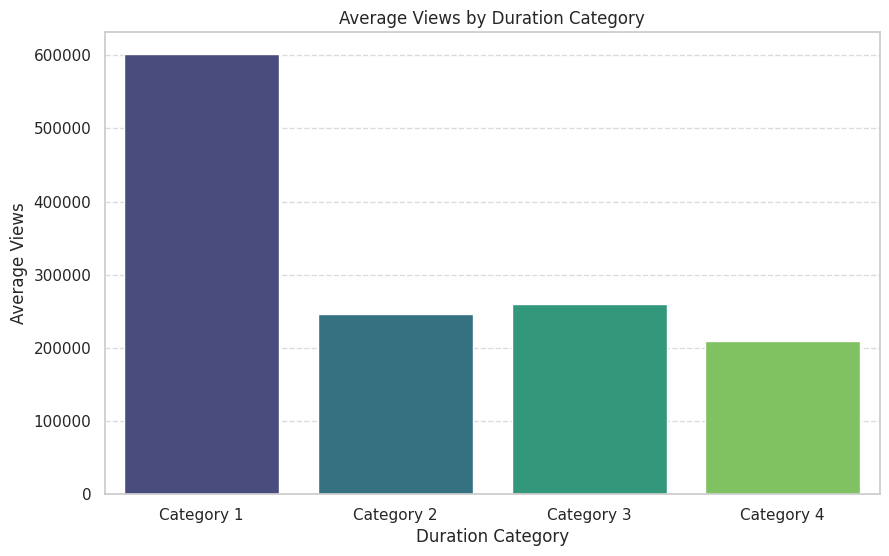

In [ ]:
# Calculate mean views per duration category
grouped_views = df2.groupby("duration_category")["views"].mean().reindex(['Category 1', 'Category 2', 'Category 3', 'Category 4'])
plt.figure(figsize=(10, 6))
sns.barplot(x=grouped_views.index, y=grouped_views.values, hue=grouped_views.index, palette='viridis', legend=False)
plt.title('Average Views by Duration Category')
plt.xlabel('Duration Category')
plt.ylabel('Average Views')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
video_counts = df2.groupby("duration_category").size()
video_counts

,0
duration_category,
Category 1,586
Category 2,276
Category 3,164
Category 4,292


In [ ]:
channel_per_category = (df2.groupby(["duration_category", "channel"])["views"].sum().reset_index())
# ambil top channel tiap kategori
top_channel = channel_per_category.sort_values(["duration_category", "views"], ascending=[True, False]).groupby("duration_category").head(5)
top_channel

,duration_category,channel,views
20,Category 1,Akmal Tubs,33012783
116,Category 1,Dr. Danny Guo,32755835
149,Category 1,G Logics,26659689
197,Category 1,JOOZY,26309788
497,Category 1,ectoxu,22104712
747,Category 2,The Johnson Brothers,37519714
707,Category 2,Prashant Kirad Shorts,11297355
742,Category 2,TECH-iELA Shorts,3157720
541,Category 2,Abhasa - Mental Health,1929255
689,Category 2,Naphtali Rosenberg,1648736


In [ ]:
df2["publishedAt"] = pd.to_datetime(df2["publishedAt"])
df2["year"] = df2["publishedAt"].dt.year
videos_per_year = df2.groupby("year").size()
videos_per_year

,0
year,
2018,1
2020,1
2021,4
2022,7
2023,44
2024,114
2025,529
2026,614


The three figures collectively illustrate the rapid emergence and growth of brainrot-related content on YouTube over time. Based on the data, the number of videos began to increase gradually in 2023 and then rose sharply in 2024, reaching a peak in 2025 and continuing to grow in 2026. This trend aligns with the period when the term brainrot started to gain popularity in online culture, suggesting that the increase in content production reflects the viral spread of the term itself.

This pattern is further reinforced by the total views per year, which also show a significant increase starting in 2023 and peaking in 2025. The parallel growth between the number of videos and total views indicates that the rise in content is accompanied by increased audience engagement, suggesting a growing interest in the topic. However, a slight decline in 2026 may be due to incomplete data or temporal bias, as newer videos have had less time to accumulate views.

Moreover, when analyzing total views by duration category, it is evident that short-duration videos (Category 1, less than 60 seconds) dominate in terms of total views, especially during the peak period. This finding highlights the strong influence of short-form content, such as YouTube Shorts, in driving engagement. The dominance of short videos suggests that audiences tend to consume quick, repetitive, and easily digestible content, which aligns with the characteristics often associated with doomscrolling behavior.

Overall, these findings suggest that the rise of brainrot content is closely linked to the increasing consumption of short-form videos, particularly since 2023. The data supports the argument that the viral spread of the term coincides with shifts in user behavior toward high-frequency, low-duration content consumption, reinforcing concerns about reduced attention span and excessive digital engagement.

**vISUAL 1**

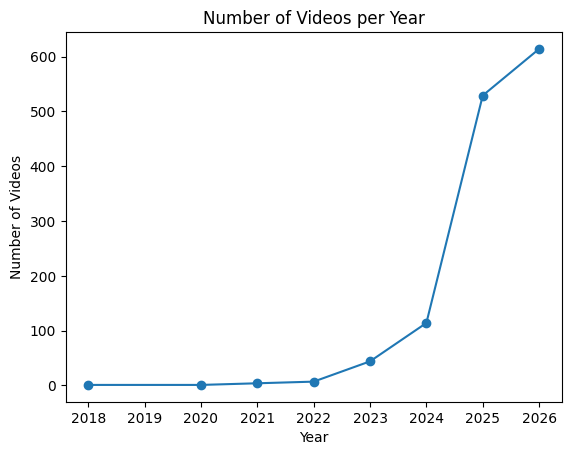

In [ ]:
plt.figure()
videos_per_year.plot(kind="line", marker="o")
plt.title("Number of Videos per Year")
plt.xlabel("Year")
plt.ylabel("Number of Videos")
plt.show()

**Visual 2**

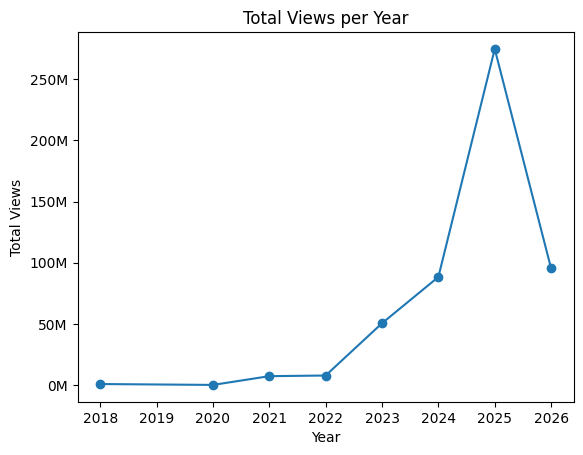

In [ ]:
import matplotlib.ticker as ticker
views_per_year = df2.groupby("year")["views"].sum()
views_per_year.plot(kind="line", marker="o")
plt.title("Total Views per Year")
plt.xlabel("Year")
plt.ylabel("Total Views")
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x/1e6)}M')
)
plt.show()

**Visual 3**

<Figure size 640x480 with 0 Axes>

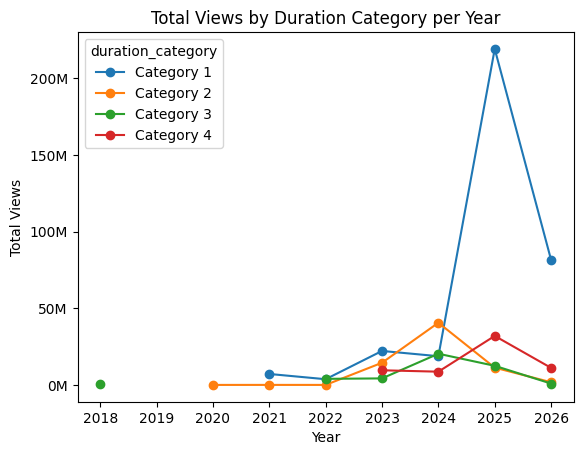

In [ ]:
views_sum = df2.groupby(["year", "duration_category"])["views"].sum().unstack()
plt.figure()
views_sum.plot(marker="o")
plt.title("Total Views by Duration Category per Year")
plt.xlabel("Year")
plt.ylabel("Total Views")
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x/1e6)}M')
)
plt.show()


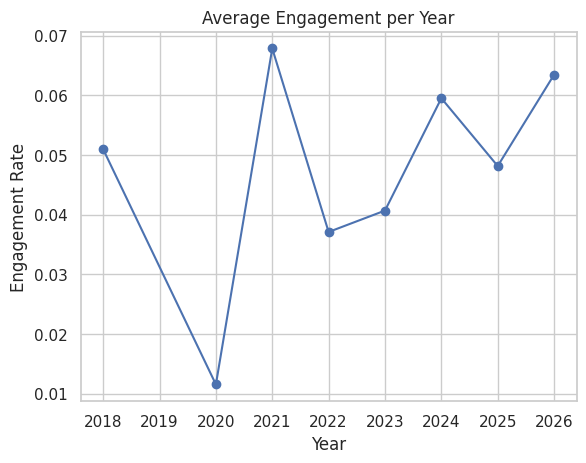

In [ ]:
df2["engagement"] = (df2["likes"] + df2["comments"]) / df2["views"]
engagement_per_year = df2.groupby("year")["engagement"].mean()
engagement_per_year.plot(kind="line", marker="o")
plt.title("Average Engagement per Year")
plt.xlabel("Year")
plt.ylabel("Engagement Rate")
plt.show()

seperti ini menjadi menarik karena trend brainrot yang makin banyak dibahas, disatu sisi kayak hal yang orang awareness tapi disisi lain banyak juga yang malah memanfaatkan si fenomena brainrot ini, sehingga banyak yang memproduksi video dengan durasi yang pendek, akibat orang2 yang lebih tertarik akan si video pendek ini


In [ ]:
top_channel_all = (df2.groupby("channel")["views"].sum().sort_values(ascending=False).head(5))
top_channel_all

,views
channel,
The Johnson Brothers,37519714
Akmal Tubs,33012783
Dr. Danny Guo,32755835
G Logics,26659689
JOOZY,26309788


In [ ]:
top5 = df2.sort_values(by="views", ascending=False).head(5)
top5[["title", "channel", "views"]]

,title,channel,views
255,POV: You accidentally doomscroll for too long ...,The Johnson Brothers,37519714
175,Stumble Guys 2025 vs 2020 Old 🥹❤️‍🩹,Akmal Tubs,33012783
708,Why You Can’t Stop Scrolling: The Skinner Box ...,G Logics,26659689
800,Stop Scrolling Your Phone! 😳📱,JOOZY,24702405
258,Doomscrolling with a Derm #dermatologist #skin...,Dr. Danny Guo,22408998


In [ ]:
top_videos = df2.sort_values("views", ascending=False).head(10)
top_videos[["title", "channel", "duration_category", "views"]]

,title,channel,duration_category,views
255,POV: You accidentally doomscroll for too long ...,The Johnson Brothers,Category 2,37519714
175,Stumble Guys 2025 vs 2020 Old 🥹❤️‍🩹,Akmal Tubs,Category 1,33012783
708,Why You Can’t Stop Scrolling: The Skinner Box ...,G Logics,Category 1,26659689
800,Stop Scrolling Your Phone! 😳📱,JOOZY,Category 1,24702405
258,Doomscrolling with a Derm #dermatologist #skin...,Dr. Danny Guo,Category 1,22408998
75,The best glitch for stealing in Steal a Brainrot,ectoxu,Category 1,22104712
1251,You’ll Stop Wasting Your Time After This TED T...,BoltMotivation,Category 1,18150501
200,Naas nya pengguna mesin rumput #shorts,Dayat slebew,Category 1,13742340
913,Stop Scrolling 😡| Motivation for Students| #mo...,Prashant Kirad Shorts,Category 2,11297355
277,Doomscrolling with a Derm #dermatologist #skin...,Dr. Danny Guo,Category 1,9761321


In [ ]:
top_videos_per_channel = (df2.sort_values("views", ascending=False).groupby(["year", "channel"]))
top_videos_per_channel[["year", "channel", "title", "views","duration_category"]].head(5)

,year,channel,title,views,duration_category
255,2024,The Johnson Brothers,POV: You accidentally doomscroll for too long ...,37519714,Category 2
175,2025,Akmal Tubs,Stumble Guys 2025 vs 2020 Old 🥹❤️‍🩹,33012783,Category 1
708,2025,G Logics,Why You Can’t Stop Scrolling: The Skinner Box ...,26659689,Category 1
800,2026,JOOZY,Stop Scrolling Your Phone! 😳📱,24702405,Category 1
258,2025,Dr. Danny Guo,Doomscrolling with a Derm #dermatologist #skin...,22408998,Category 1
...,...,...,...,...,...
595,2026,Life Unlocked,The Reason Why You Can't Stop Doom Scrolling,0,Category 4
603,2026,Eimaranddaniel,Doom scrolling NEW VID AT 7:30 or 8:00,0,Category 3
699,2026,Warp Reader,replace doom scrolling,0,Category 1
684,2026,Enderslayereditz,pov if doom scrolling was a job,0,Category 1


In [ ]:
summary = df2.groupby(["duration_category", "channel"])["views"].mean().reset_index()
top_combo = summary.sort_values(["duration_category", "views"], ascending=[True, False]).groupby("duration_category").head()
top_combo

,duration_category,channel,views
20,Category 1,Akmal Tubs,33012783.0
149,Category 1,G Logics,26659689.0
497,Category 1,ectoxu,22104712.0
60,Category 1,BoltMotivation,18150501.0
101,Category 1,Dayat slebew,13742340.0
747,Category 2,The Johnson Brothers,37519714.0
707,Category 2,Prashant Kirad Shorts,11297355.0
742,Category 2,TECH-iELA Shorts,3157720.0
541,Category 2,Abhasa - Mental Health,1929255.0
733,Category 2,Spark Growth,1559715.0


In [ ]:
for i, row in top5.iterrows():
    print(f"Title   : {row['title']}")
    print(f"Channel : {row['channel']}")
    print(f"Views   : {row['views']}")
    print("-" * 40)

Title   : POV: You accidentally doomscroll for too long 😵‍💫 #theboys #viral #shorts #interstellar
Channel : The Johnson Brothers
Views   : 37519714
----------------------------------------
Title   : Stumble Guys 2025 vs 2020 Old 🥹❤️‍🩹
Channel : Akmal Tubs
Views   : 33012783
----------------------------------------
Title   : Why You Can’t Stop Scrolling: The Skinner Box Explained🐀
Channel : G Logics
Views   : 26659689
----------------------------------------
Title   : Stop Scrolling Your Phone! 😳📱
Channel : JOOZY
Views   : 24702405
----------------------------------------
Title   : Doomscrolling with a Derm #dermatologist #skincare
Channel : Dr. Danny Guo
Views   : 22408998
----------------------------------------
